# Parsing TYNDP data for SHRECC

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import pickle
import os
import matplotlib.pyplot as plt
import xarray as xr

# import plotly.express as px

%load_ext jupyter_black

# Import TYNDP data

In [2]:
filepath_xlsb = "../data/tyndp/MMStandardOutputFile_DE2050_Plexos_CY2009_v11_SoS.xlsb"
filepath_prod_pkl = "../data/tyndp/DE2050_CY2009_prod.pkl"
filepath_trade_pkl = "../data/tyndp/DE2050_CY2009_trade.pkl"
filepath_concordance_techs = "../data/tyndp/tyndp_ei_mapping.xlsx"
filepath_concordance_nodes = "../data/tyndp/tyndp_country_mapping.xlsx"

In [3]:
if os.path.isfile(filepath_prod_pkl):
    with open(filepath_prod_pkl, "rb") as f:
        prod_DE2050_CY2009 = pickle.load(f)
else:
    prod_DE2050_CY2009 = pd.read_excel(
        io=filepath_xlsb,
        sheet_name="Hourly Market Data emarket",
        header=[10, 11, 12],
        index_col=[0, 1],
        engine="pyxlsb",
    )
    with open(filepath_prod_pkl, "wb") as f:
        pickle.dump(prod_DE2050_CY2009, f)

if os.path.isfile(filepath_trade_pkl):
    with open(filepath_trade_pkl, "rb") as f:
        trade_DE2050_CY2009 = pickle.load(f)
else:
    trade_DE2050_CY2009 = pd.read_excel(
        io=filepath_xlsb,
        sheet_name="Crossborder exchanges",
        header=[10],
        index_col=[0, 1],
        engine="pyxlsb",
    )
    with open(filepath_trade_pkl, "wb") as f:
        pickle.dump(trade_DE2050_CY2009, f)

## Production

In [4]:
# This is the raw data from TYNDP
# Parsing and cleaning includes:
# - keep only the columns with production data for nodes XX00, XX00RETE
# - remove columns where all values are NaN
# - set a proper datetime index

prod_DE2050_CY2009.head()

,Category,Nuclear [MW],Lignite old 1 [MW],Lignite old 2 [MW],Lignite new [MW],Lignite CCS [MW],Hard coal old 1 [MW],Hard coal old 2 [MW],Hard coal new [MW],Hard coal CCS [MW],Gas conventional old 1 [MW],...,Hydrogen CCGT [MW],Demand Side Response [MW],CH4 Heat Pump (load) [MW],H2 Heat Pump (load) [MW],Adequacy [MW],Demand [MW]\n(losses included),Balance [MW],Dumped Energy [MW],Energy Not Served [MW],Marginal Cost [€]
,Country,AL00,AL00,AL00,AL00,AL00,AL00,AL00,AL00,AL00,AL00,...,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE,UKNIRETE
,Date /Code,AL00_1,AL00_2,AL00_3,AL00_4,AL00_5,AL00_6,AL00_7,AL00_8,AL00_9,AL00_10,...,UKNIRETE_52,UKNIRETE_DSR,UKNIRETE_HCH4,UKNIRETE_HH2,UKNIRETE_SoS,UKNIRETE_LOAD,UKNIRETE_Balance,UKNIRETE_Dump,UKNIRETE_ENS,UKNIRETE_Mgl Cost
1,01JAN00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,NaN,2214,-2214,0,0,237
2,01JAN01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,NaN,2206,-2206,0,0,233
3,01JAN02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,NaN,2177,-2177,0,0,231
4,01JAN03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,NaN,2173,-2173,0,0,231
5,01JAN04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,NaN,2150,-2150,0,0,231


In [5]:
# index in the proper format
dt = pd.to_datetime(
    prod_DE2050_CY2009.index.get_level_values(1) + "2050", format="%d%b%H:%M%Y"
)

In [6]:
# Let's have a look at production data first
prod_DE2050_CY2009.dropna(axis=1, how="all", inplace=True)
prod_DE2050_CY2009.index = dt
prod_DE2050_CY2009.head()

Category            Gas CCGT old 2 [MW] Gas CCGT new [MW] Run-of-River [MW]  \
Country                            AL00              AL00              AL00   
Date /Code                      AL00_13           AL00_14           AL00_26   
2050-01-01 00:00:00                   0               110               193   
2050-01-01 01:00:00                   0               100               193   
2050-01-01 02:00:00                   0                90               193   
2050-01-01 03:00:00                   0                 0               193   
2050-01-01 04:00:00                   0                 0               193   

Category            Reservoir [MW] Wind Onshore [MW]  \
Country                       AL00              AL00   
Date /Code                 AL00_27           AL00_31   
2050-01-01 00:00:00           1904                40   
2050-01-01 01:00:00           1904                43   
2050-01-01 02:00:00           1904                48   
2050-01-01 03:00:00           1904                55   
2050-01-01 04:00:00           1904                59   

Category            Solar (Photovoltaic) [MW] Demand [MW]\n(losses included)  \
Country                                  AL00                           AL00   
Date /Code                            AL00_33                      AL00_LOAD   
2050-01-01 00:00:00                         0                           1145   
2050-01-01 01:00:00                         0                           1006   
2050-01-01 02:00:00                         0                            923   
2050-01-01 03:00:00                         0                            885   
2050-01-01 04:00:00                         0                            892   

Category            Balance [MW] Dumped Energy [MW] Energy Not Served [MW]  \
Country                     AL00               AL00                   AL00   
Date /Code          AL00_Balance          AL00_Dump               AL00_ENS   
2050-01-01 00:00:00         1102                  0                      0   
2050-01-01 01:00:00         1234                  0                      0   
2050-01-01 02:00:00         1312                  0                      0   
2050-01-01 03:00:00         1267                  0                      0   
2050-01-01 04:00:00         1265                  0                      0   

Category             ...                Marginal Cost [€]  \
Country              ...     UKNI SRES          UKNI SRES   
Date /Code           ... UKNI SRES_ENS UKNI SRES_Mgl Cost   
2050-01-01 00:00:00  ...             0              -1000   
2050-01-01 01:00:00  ...             0              -1000   
2050-01-01 02:00:00  ...             0              -1000   
2050-01-01 03:00:00  ...             0              -1000   
2050-01-01 04:00:00  ...             0              -1000   

Category            Solar (Photovoltaic) [MW] CH4 Heat Pump (load) [MW]  \
Country                              UKNIRETE                  UKNIRETE   
Date /Code                        UKNIRETE_33             UKNIRETE_HCH4   
2050-01-01 00:00:00                         0                         0   
2050-01-01 01:00:00                         0                         0   
2050-01-01 02:00:00                         0                         0   
2050-01-01 03:00:00                         0                         0   
2050-01-01 04:00:00                         0                         0   

Category            H2 Heat Pump (load) [MW] Demand [MW]\n(losses included)  \
Country                             UKNIRETE                       UKNIRETE   
Date /Code                      UKNIRETE_HH2                  UKNIRETE_LOAD   
2050-01-01 00:00:00                        0                           2214   
2050-01-01 01:00:00                        0                           2206   
2050-01-01 02:00:00                        0                           2177   
2050-01-01 03:00:00                        0                           2173   
2050-01-0

In [7]:
test = prod_DE2050_CY2009.xs("AL00", level=1, axis=1)

test.columns

MultiIndex([(           'Gas CCGT old 2 [MW]',       'AL00_13'),
            (             'Gas CCGT new [MW]',       'AL00_14'),
            (             'Run-of-River [MW]',       'AL00_26'),
            (                'Reservoir [MW]',       'AL00_27'),
            (             'Wind Onshore [MW]',       'AL00_31'),
            (     'Solar (Photovoltaic) [MW]',       'AL00_33'),
            ('Demand [MW]\n(losses included)',     'AL00_LOAD'),
            (                  'Balance [MW]',  'AL00_Balance'),
            (            'Dumped Energy [MW]',     'AL00_Dump'),
            (        'Energy Not Served [MW]',      'AL00_ENS'),
            (             'Marginal Cost [€]', 'AL00_Mgl Cost')],
           names=['Category', 'Date /Code'])

In [8]:
# Production should equal Demand + Commercial balance

In [9]:
test.iloc[:, :6].sum(1) - test[["Demand [MW]\n(losses included)", "Balance [MW]"]].sum(
    1
)

2050-01-01 00:00:00    0
2050-01-01 01:00:00    0
2050-01-01 02:00:00    0
2050-01-01 03:00:00    0
2050-01-01 04:00:00   -1
                      ..
2050-12-30 19:00:00    1
2050-12-30 20:00:00    0
2050-12-30 21:00:00    0
2050-12-30 22:00:00    0
2050-12-30 23:00:00    1
Length: 8736, dtype: int64

### Technologies

In [10]:
# Isolate sources
sources = prod_DE2050_CY2009.columns.levels[0]

In [11]:
concordance = pd.read_excel(
    filepath_concordance_techs, sheet_name="concordance", index_col=0, skipfooter=1
).iloc[:, :-1]
concordance = concordance.loc[concordance.sum(1) > 0, concordance.sum() > 0]
concordance /= concordance.sum()
concordance.columns.name = "Category"
concordance.head(2)

Category,Gas CCGT CCS [MW],Gas CCGT new [MW],Gas CCGT old 1 [MW],Gas CCGT old 2 [MW],Gas CCGT present 1 [MW],Gas CCGT present 2 [MW],Gas OCGT new [MW],Gas OCGT old [MW],Gas conventional old 1 [MW],Gas conventional old 2 [MW],...,Others non-renewable [MW],Others renewable [MW],Pump Storage - Closed Loop (turbine) [MW],Pump Storage - Open Loop (turbine) [MW],Reservoir [MW],Run-of-River [MW],Solar (Photovoltaic) [MW],Solar (Thermal) [MW],Wind Offshore [MW],Wind Onshore [MW]
premise activity,,,,,,,,,,,,,,,,,,,,,
"electricity production, at biomass-fired IGCC power plant, pre, pipeline 200km, storage 1000m",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"electricity production, at co-generation natural gas-fired power plant, post, pipeline 200km, storage 1000m",0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Nodes

In [12]:
country = "LU"

idx = pd.IndexSlice

index_c = [c for c in prod_DE2050_CY2009.columns.levels[1] if c.startswith(country)]

index_t = (
    prod_DE2050_CY2009.loc[:, idx[:, index_c]]
    .columns.get_level_values("Category")
    .isin(concordance.columns)
)

In [13]:
sample = (
    prod_DE2050_CY2009.loc[:, idx[:, index_c]].dropna(how="all", axis=1).loc[:, index_t]
)

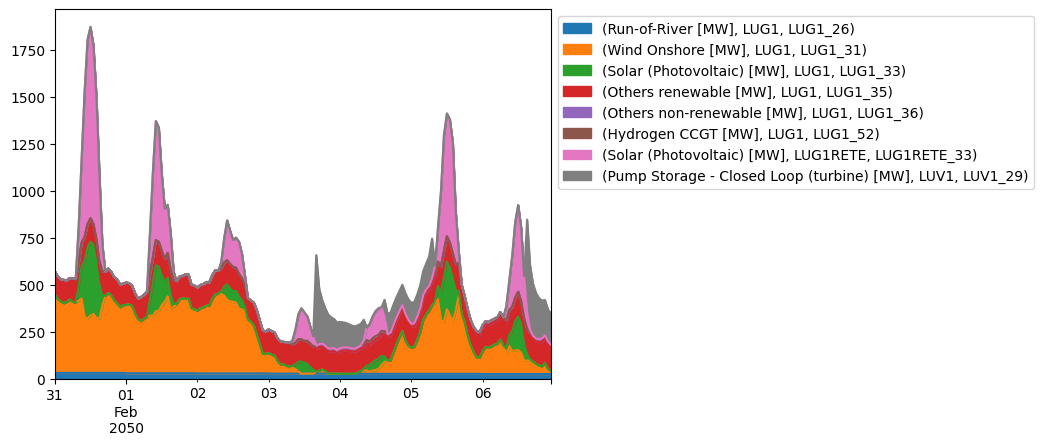

In [14]:
month = 2

ax = sample.iloc[(month - 1) * 30 * 24 : ((month - 1) * 30 + 7) * 24, :].plot.area()
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

In [15]:
countries = prod_DE2050_CY2009.columns.get_level_values("Country").unique()

In [16]:
sp.linalg.block_diag(*[concordance.to_numpy()] * len(countries)).shape

(8436, 7548)

In [17]:
concordance_full = pd.DataFrame(
    sp.linalg.block_diag(*[concordance.to_numpy()] * len(countries)),
    index=pd.MultiIndex.from_product([countries, concordance.index]),
    columns=pd.MultiIndex.from_product([countries, concordance.columns]),
)

In [18]:
concordance_like_prod = concordance_full.reindex(
    prod_DE2050_CY2009.columns.droplevel("Date /Code").swaplevel(), axis=1
).fillna(0)
concordance_like_prod.columns = prod_DE2050_CY2009.columns
concordance_like_prod.head(2)

Category                                                   Gas CCGT old 2 [MW]  \
Country                                                                   AL00   
Date /Code                                                             AL00_13   
Country premise activity                                                         
AL00    electricity production, at biomass-fired IGCC p...                 0.0   
        electricity production, at co-generation natura...                 0.0   

Category                                                   Gas CCGT new [MW]  \
Country                                                                 AL00   
Date /Code                                                           AL00_14   
Country premise activity                                                       
AL00    electricity production, at biomass-fired IGCC p...               0.0   
        electricity production, at co-generation natura...               0.0   

Category                                                   Run-of-River [MW]  \
Country                                                                 AL00   
Date /Code                                                           AL00_26   
Country premise activity                                                       
AL00    electricity production, at biomass-fired IGCC p...               0.0   
        electricity production, at co-generation natura...               0.0   

Category                                                   Reservoir [MW]  \
Country                                                              AL00   
Date /Code                                                        AL00_27   
Country premise activity                                                    
AL00    electricity production, at biomass-fired IGCC p...            0.0   
        electricity production, at co-generation natura...            0.0   

Category                                                   Wind Onshore [MW]  \
Country                                                                 AL00   
Date /Code                                                           AL00_31   
Country premise activity                                                       
AL00    electricity production, at biomass-fired IGCC p...               0.0   
        electricity production, at co-generation natura...               0.0   

Category                                                   Solar (Photovoltaic) [MW]  \
Country                                                                         AL00   
Date /Code                                                                   AL00_33   
Country premise activity                                                               
AL00    electricity production, at biomass-fired IGCC p...                       0.0   
        electricity production, at co-generation natura...                       0.0   

Category                                                   Demand [MW]\n(losses included)  \
Country                                                                              AL00   
Date /Code                                                                      AL00_LOAD   
Country premise activity                                                                    
AL00    electricity production, at biomass-fired IGCC p...                            0.0   
        electricity production, at co-generation natura...                            0.0   

Category                                                   Balance [MW]  \
Country                                                            AL00   
Date /Code                                                 AL00_Balance   
Country premise activity                                                  
AL00    electricity production, at biomass-fired IGCC p...          0.0   
        electricity production, at co-generation natura...          0.0   

Category                                                   Dum

In [19]:
prod_DE2050_CY2009.columns.equals(concordance_like_prod.columns)

True

In [20]:
prod_values = prod_DE2050_CY2009.to_numpy(dtype="float64", copy=False)
conc_sparse = sp.sparse.csr_matrix(
    concordance_like_prod.to_numpy(dtype="float64", copy=False)
)
prod_agg_values = prod_values @ conc_sparse.T

In [21]:
prod_agg_ei = pd.DataFrame(
    prod_agg_values, index=prod_DE2050_CY2009.index, columns=concordance_like_prod.index
)

In [22]:
concordance_nodes = pd.read_excel(
    filepath_concordance_nodes, sheet_name="countries", index_col=0
)

In [23]:
prod_agg_ei.shape

(8736, 8436)

In [24]:
# Version with ecoinvent classification
prod_agg_ei = (
    prod_agg_ei.rename(
        concordance_nodes["Country code"].to_dict(), level="Country", axis=1
    )
    .groupby(["Country", "premise activity"], axis=1)
    .sum()
)

C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\410918463.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(["Country", "premise activity"], axis=1)


In [25]:
# Let's keep one version in ENTSOE format
prod_agg_entsoe = (
    prod_DE2050_CY2009.rename(
        concordance_nodes["Country code"].to_dict(), level="Country", axis=1
    )
    .groupby(["Country", "Category"], axis=1)
    .sum()
)

prod_agg_entsoe = prod_agg_entsoe.loc[
    :, prod_agg_entsoe.columns.get_level_values("Category").isin(concordance.columns)
]

C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\2681447829.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(["Country", "Category"], axis=1)


## Trade

Trade data requires special attention. Nodes are treated separately (this is OK), but it looks like various interconnection alternatives exist (Concept 1/Concept 2), this is unclear.

In [26]:
# same for trade data
trade_DE2050_CY2009.dropna(axis=1, how="all", inplace=True)
trade_DE2050_CY2009.index = dt
trade_DE2050_CY2009.head()

,AL00-GR00,AL00-GR00 Concept 1,AL00-GR00 Concept 2,AL00-ME00,AL00-ME00 Concept 1,AL00-ME00 Concept 2,AL00-ME00 Concept 3,AL00-ME00 Concept 4,AL00-MK00,AL00-MK00 Concept 1,...,UKNIEV-UKNIRETE,UKNIRETE-UKNIEV,UKNI-UKNIEV,UKNI-UKNIRETE,UKOH001OHEL-UK00 EXP,UKOH003OHEL-UK00 EXP,UKOH004OHEL-IE00 EXP,UKOH004OHEL-UK00 EXP,UKOH005OHEL-UK00 EXP,UKOH006OHEL-UK00 EXP
2050-01-01 00:00:00,-600,-500,-500,330,468,468,468,424,-330,-330,...,0,0,0,2214,-3877,-2377,-2687,5610,8276,6526
2050-01-01 01:00:00,-600,-500,-500,298,439,439,439,383,-185,-185,...,0,0,0,2206,-3877,-4437,-2574,5610,8261,6397
2050-01-01 02:00:00,-600,-500,-500,314,456,456,456,405,-191,-191,...,0,2,1,2179,-3877,-4844,-2489,5610,8201,6139
2050-01-01 03:00:00,-600,-500,-500,323,463,463,463,416,-234,-234,...,0,2,1,2175,-3877,-4627,-2291,5610,8177,6053
2050-01-01 04:00:00,-600,-500,-500,329,467,467,467,422,-247,-247,...,0,1,1,2152,-3877,-4459,-2093,5610,8226,5967


In [27]:
# We want to reshape the trade data with origin-destination pairs as multiindex columns
parsed = trade_DE2050_CY2009.columns.to_series().str.extract(
    r"^\s*(?P<origin>.+?)\s*-\s*(?P<destination>.+?)\s*$"
)

# If any origin/destination is NaN, raise a flag
bad_cols = trade_DE2050_CY2009.columns[
    parsed["origin"].isna() | parsed["destination"].isna()
]
print(bad_cols)

# Clean the names by removing trailing "Concept N" and stripping whitespace
parsed["origin"] = (
    parsed["origin"].str.replace(r"\s*/?Concept\s+\d+\s*$", "", regex=True).str.strip()
)

parsed["destination"] = (
    parsed["destination"]
    .str.replace(r"\s*/?Concept\s+\d+\s*$", "", regex=True)
    .str.strip()
)

# Apply the cleaned names to the columns
trade = trade_DE2050_CY2009.copy()
trade.columns = pd.MultiIndex.from_arrays(
    [parsed["origin"], parsed["destination"]], names=["origin", "destination"]
)

# Origin-destination node pairs for each hour
od_hourly = trade.T.groupby(level=["origin", "destination"]).sum().T

Index([], dtype='object')


In [28]:
od_hourly.head()

origin               AL00                    AT00                             \
destination          GR00  ME00 MK00  RS00 AT00EV AT00RETE  CH00  CZ00  DE00   
2050-01-01 00:00:00 -1600  2158 -705  1250      0     7605 -1700  2400  7147   
2050-01-01 01:00:00 -1600  1998 -414  1250      0     7465 -1700  2400  6801   
2050-01-01 02:00:00 -1600  2087 -426  1250      0     7358 -1700  2400  6510   
2050-01-01 03:00:00 -1600  2128 -512  1250      0     7266 -1700  2400  6702   
2050-01-01 04:00:00 -1600  2152 -538  1250      0     7192 -1700  2400  6902   

origin                     ...     UKNI UKNIEV          UKNIRETE UKOH001OHEL  \
destination          HU00  ... UKNIRETE   UKNI UKNIRETE   UKNIEV    UK00 EXP   
2050-01-01 00:00:00 -1124  ...     2214      0        0        0       -3877   
2050-01-01 01:00:00 -1262  ...     2206      0        0        0       -3877   
2050-01-01 02:00:00 -1336  ...     2179      0        0        2       -3877   
2050-01-01 03:00:00 -1343  ...     2175      0        0        2       -3877   
2050-01-01 04:00:00 -1258  ...     2152      0        0        1       -3877   

origin              UKOH003OHEL UKOH004OHEL          UKOH005OHEL UKOH006OHEL  
destination            UK00 EXP    IE00 EXP UK00 EXP    UK00 EXP    UK00 EXP  
2050-01-01 00:00:00       -2377       -2687     5610        8276        6526  
2050-01-01 01:00:00       -4437       -2574     5610        8261        6397  
2050-01-01 02:00:00       -4844       -2489     5610        8201        6139  
2050-01-01 03:00:00       -4627       -2291     5610        8177        6053  
2050-01-01 04:00:00       -4459       -2093     5610        8226        5967  

[5 rows x 388 columns]

In [29]:
lu_imports = od_hourly.columns.get_level_values("destination").str.startswith(
    "LU"
) & ~od_hourly.columns.get_level_values("origin").str.startswith("LU")

lu_exports = od_hourly.columns.get_level_values("origin").str.startswith("LU")


print(od_hourly.loc[:, lu_imports].head())
print(od_hourly.loc[:, lu_exports].head())

origin              BE00                  DE00      FR00
destination         LUB1 LUG1 LUG1 Real 1 LUG1 LUV1 LUF1
2050-01-01 00:00:00   27  800         500  374    0  121
2050-01-01 01:00:00   25  800         500  332    0  134
2050-01-01 02:00:00   26  800         500  316    0  125
2050-01-01 03:00:00   25  800         500  321    0  130
2050-01-01 04:00:00   25  800         500  313    0  113
origin                LUG1          LUG1EV          LUG1RETE
destination         LUG1EV LUG1RETE   LUG1 LUG1RETE   LUG1EV
2050-01-01 00:00:00    228     1098      0        0      327
2050-01-01 01:00:00    228     1126      0        0      367
2050-01-01 02:00:00    227     1150      0        0      387
2050-01-01 03:00:00    222     1142      0        0      375
2050-01-01 04:00:00    218     1129      0        0      351


In [30]:
od_hourly.loc[:, lu_imports].sum()

origin  destination
BE00    LUB1            248394
        LUG1           1926318
        LUG1 Real 1    1051391
DE00    LUG1           6219713
        LUV1            343015
FR00    LUF1           1470076
dtype: int64

C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\2557823950.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  od_hourly.loc[:, lu_imports].groupby(level="origin", axis=1).sum().plot(figsize=(12, 6))


<Axes: >

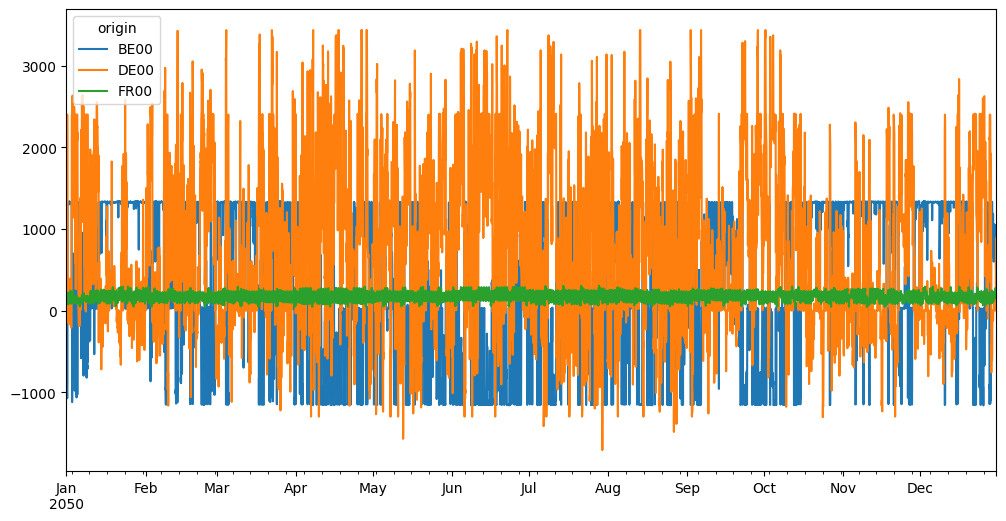

In [31]:
od_hourly.loc[:, lu_imports].groupby(level="origin", axis=1).sum().plot(figsize=(12, 6))

C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\3616664322.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  lu_imports_summary = od_hourly.loc[:, lu_imports].groupby(level="origin", axis=1).sum()


Text(0, 0.5, 'MW')

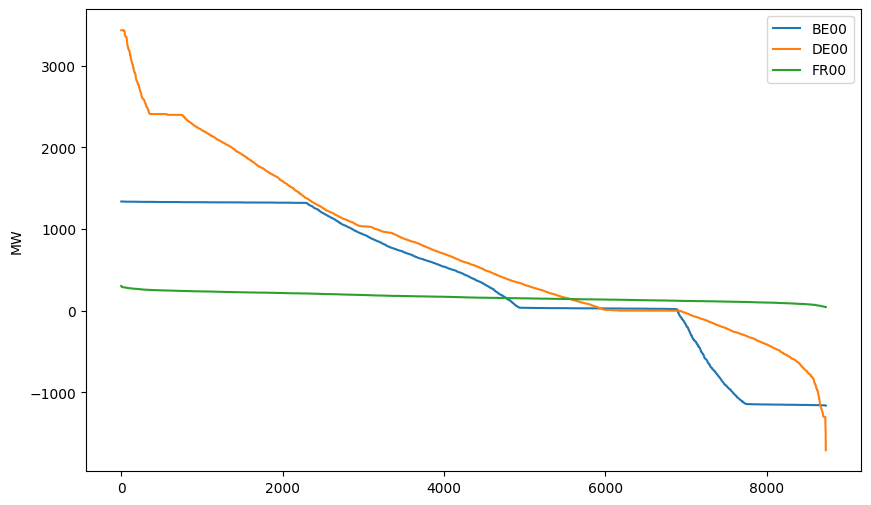

In [32]:
lu_imports_summary = od_hourly.loc[:, lu_imports].groupby(level="origin", axis=1).sum()

fig, ax = plt.subplots(figsize=(10, 6))

for c in ["BE00", "DE00", "FR00"]:
    lu_imports_summary[c].sort_values(ascending=False).reset_index(drop=True).plot(
        ax=ax
    )

ax.legend()
ax.set_ylabel("MW")

In [33]:
# Let's use Ember mapping to aggregate nodes

concordance_connections = pd.read_excel(
    filepath_concordance_nodes, sheet_name="connections", index_col=0
)
concordance_connections = concordance_connections[
    ~concordance_connections.index.duplicated(keep="first")
]

In [34]:
trade_DE2050_CY2009.columns.name = "BZ line"

In [35]:
trade_DE2050_CY2009.columns = pd.MultiIndex.from_frame(
    concordance_connections.reindex(trade_DE2050_CY2009.columns, axis=0).reset_index()
)

In [36]:
trade_agg = trade_DE2050_CY2009.groupby(
    level=["Country from", "Country to"], axis=1
).sum()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\3283422206.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trade_agg = trade_DE2050_CY2009.groupby(


In [37]:
# Put everything as positive values
pos = trade_agg.clip(lower=0).copy()
neg_rev = (-trade_agg.clip(upper=0)).copy()

neg_rev.columns = pd.MultiIndex.from_arrays(
    [
        neg_rev.columns.get_level_values("Country to"),
        neg_rev.columns.get_level_values("Country from"),
    ],
    names=["Country from", "Country to"],
)

trade_directional = (
    pd.concat([pos, neg_rev], axis=1)
    .T.groupby(level=["Country from", "Country to"])
    .sum()
    .T.swaplevel(axis=1)
)

In [38]:
# This allows the production of a bidirectional matrix for each hour
trade_directional.loc["2050-01-01 00:00:00"].unstack("Country from").fillna(0).head()

Country from,AL,AT,BA,BE,BG,CH,CY,CZ,DE,DK,...,NL,NO,PL,PT,RO,RS,SE,SI,SK,UK
Country to,,,,,,,,,,,,,,,,,,,,,
AL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT,0.0,0.0,0.0,0.0,0.0,1200.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,950.0,0.0,0.0
BA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000.0
BG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Single matrix

In [39]:
# Harmonize names in column levels
# Source = ecoinvent/premise technology, or "country from"
# Country = country where the technology is located, or "country to"
prod_agg_entsoe.columns.names = trade_directional.columns.names = ["Country", "Source"]
trade_directional.xs("FR", level="Country", axis=1).head()

Source,BE,CH,DE,ES,IE,IT,LU,UK
2050-01-01 00:00:00,0,613,0,4553,700,2160,0,0
2050-01-01 01:00:00,0,0,0,1564,700,1608,0,0
2050-01-01 02:00:00,0,0,0,119,700,871,0,3
2050-01-01 03:00:00,0,0,0,0,700,2158,0,1034
2050-01-01 04:00:00,0,0,0,0,700,2158,0,2897


In [41]:
trade_directional.xs("FR", level="Source", axis=1).head()

Country,BE,CH,DE,ES,IE,IT,LU,UK
2050-01-01 00:00:00,4300,0,4800,0,0,0,121,1847
2050-01-01 01:00:00,4300,0,4800,0,0,0,134,174
2050-01-01 02:00:00,4300,0,4800,0,0,0,125,0
2050-01-01 03:00:00,4300,0,4800,1902,0,0,130,0
2050-01-01 04:00:00,4300,0,4800,3346,0,0,113,0


In [42]:
level = prod_agg_entsoe.columns.get_level_values("Country")

origin_destination_index = pd.MultiIndex.from_arrays(
    [
        level,
        *[
            prod_agg_entsoe.columns.get_level_values(name)
            for name in prod_agg_entsoe.columns.names
        ],
    ],
    names=["country from", "country to", "source"],
)

prod_agg_entsoe.columns = origin_destination_index

In [43]:
trade = pd.concat([trade_directional], keys=["trade"], names=["source"], axis=1)
trade.columns.names = ["source", "country to", "country from"]
trade.columns = trade.columns.swaplevel(0, 2)

In [44]:
Z_gross = pd.concat(
    [prod_agg_entsoe, trade], axis=1, keys=["production mix", "trade"], names=["type"]
)

In [46]:
Z_gross.head(2)

type                   production mix                                     \
country from                       AL                                      
country to                         AL                                      
source              Gas CCGT new [MW] Gas CCGT old 2 [MW] Reservoir [MW]   
2050-01-01 00:00:00               110                   0           1904   
2050-01-01 01:00:00               100                   0           1904   

type                                                             \
country from                                                      
country to                                                        
source              Run-of-River [MW] Solar (Photovoltaic) [MW]   
2050-01-01 00:00:00               193                         0   
2050-01-01 01:00:00               193                         0   

type                                                      \
country from                                          AT   
country to                                            AT   
source              Wind Onshore [MW] Hydrogen CCGT [MW]   
2050-01-01 00:00:00                40               2934   
2050-01-01 01:00:00                43               2934   

type                                                                 \
country from                                                          
country to                                                            
source              Others non-renewable [MW] Others renewable [MW]   
2050-01-01 00:00:00                       464                   502   
2050-01-01 01:00:00                       464                   502   

type                                                           ... trade  \
country from                                                   ...    SI   
country to                                                     ...    HU   
source              Pump Storage - Closed Loop (turbine) [MW]  ... trade   
2050-01-01 00:00:00                                        31  ...  1200   
2050-01-01 01:00:00                                        31  ...  1200   

type                                                                       
country from                 SK          UK                                
country to             IT    CZ    HU    BE    DE    DK    FR    IE    NL  
source              trade trade trade trade trade trade trade trade trade  
2050-01-01 00:00:00     0  1100     0  1000  1400     0     0     0  1000  
2050-01-01 01:00:00     0  1100     0  1000  1400     0     0     0  1000  

[2 rows x 522 columns]

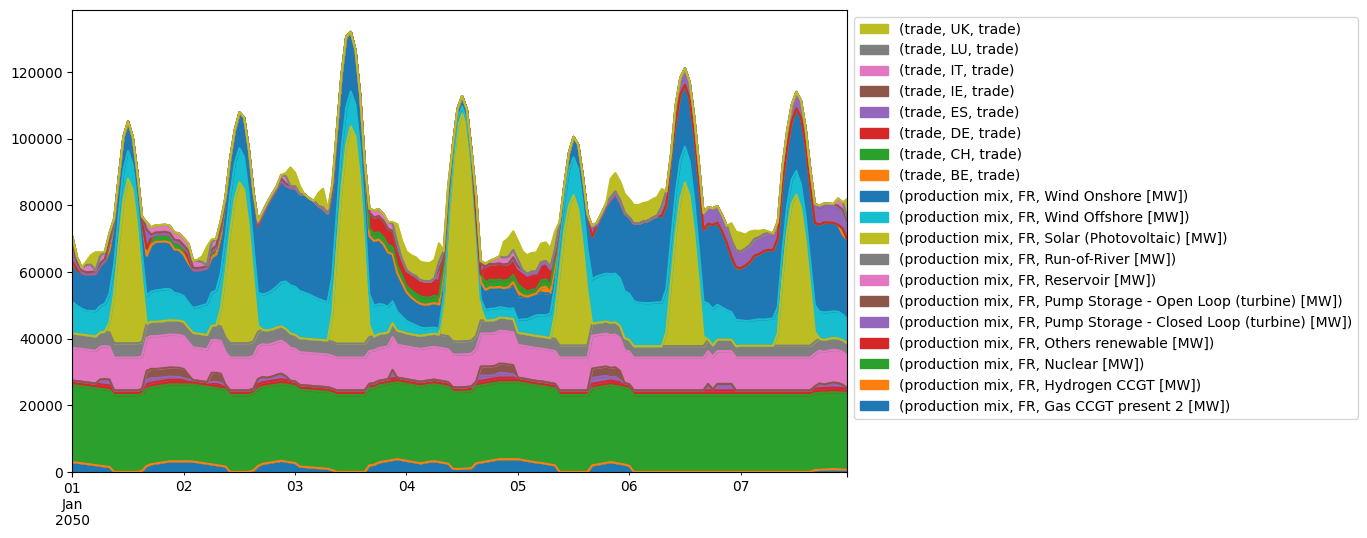

In [47]:
ax = (
    Z_gross.xs("FR", level="country to", axis=1).head(24 * 7).plot.area(figsize=(10, 6))
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc="upper left", bbox_to_anchor=(1.0, 1.0))

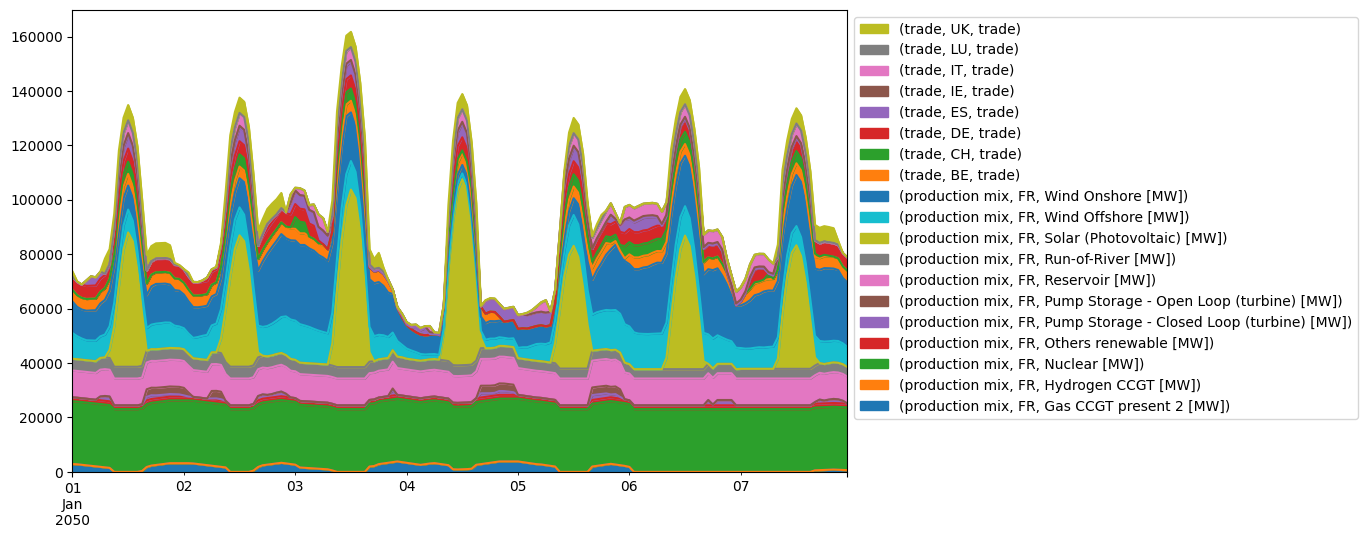

In [48]:
ax = (
    Z_gross.xs("FR", level="country from", axis=1)
    .head(24 * 7)
    .plot.area(figsize=(10, 6))
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc="upper left", bbox_to_anchor=(1.0, 1.0))

## Calculation of consumption mix (obsolete)
The naive way is to put everything in a square matrix, production mix and trade.

In [49]:
Z_test = pd.concat(
    [Z_gross.loc["2050-01-01 00:00:00"].unstack("country to").fillna(0)],
    names=["type"],
    keys=["trade"],
    axis=1,
)

Z_test = pd.concat(
    [Z_test],
    names=["source"],
    keys=["trade"],
    axis=1,
)

In [50]:
Z_test.columns.names = ["source", "type", "country"]
Z_test.index.names = ["type", "country", "source"]

Z_test = Z_test.reorder_levels([1, 2, 0], axis=1)

Z_test.head(2)

type                                        trade                             \
country                                        AL    AT AT00RETE    BA    BE   
source                                      trade trade    trade trade trade   
type           country source                                                  
production mix AL      Gas CCGT new [MW]    110.0   0.0      0.0   0.0   0.0   
                       Gas CCGT old 2 [MW]    0.0   0.0      0.0   0.0   0.0   

type                                                                      \
country                                    BE00RETE    BG BG00RETE    CH   
source                                        trade trade    trade trade   
type           country source                                              
production mix AL      Gas CCGT new [MW]        0.0   0.0      0.0   0.0   
                       Gas CCGT old 2 [MW]      0.0   0.0      0.0   0.0   

type                                              ...                    \
country                                       CY  ... SE02RETE SE03RETE   
source                                     trade  ...    trade    trade   
type           country source                     ...                     
production mix AL      Gas CCGT new [MW]     0.0  ...      0.0      0.0   
                       Gas CCGT old 2 [MW]   0.0  ...      0.0      0.0   

type                                                                      \
country                                    SE04RETE    SI SI00RETE    SK   
source                                        trade trade    trade trade   
type           country source                                              
production mix AL      Gas CCGT new [MW]        0.0   0.0      0.0   0.0   
                       Gas CCGT old 2 [MW]      0.0   0.0      0.0   0.0   

type                                                                         
country                                    SK00RETE    UK UK00RETE UKNIRETE  
source                                        trade trade    trade    trade  
type           country source                                                
production mix AL      Gas CCGT new [MW]        0.0   0.0      0.0      0.0  
                       Gas CCGT old 2 [MW]      0.0   0.0      0.0      0.0  

[2 rows x 77 columns]

In [51]:
Z_square = Z_test.reindex(Z_test.index, axis=1).fillna(0)

In [52]:
A_square = Z_square.div(Z_square.sum()).fillna(0)

In [53]:
A_square.to_clipboard()

In [54]:
L = pd.DataFrame(
    sp.linalg.inv(np.eye(A_square.shape[0]) - A_square),
    index=A_square.index,
    columns=A_square.columns,
)

In [55]:
L.loc["production mix", ("trade", "FR", "trade")].nlargest(20)

country  source                                 
FR       Nuclear [MW]                               0.326832
         Wind Onshore [MW]                          0.163628
         Reservoir [MW]                             0.139478
         Wind Offshore [MW]                         0.133741
         Run-of-River [MW]                          0.061134
         Gas CCGT present 2 [MW]                    0.040737
ES       Wind Onshore [MW]                          0.030880
FR       Others renewable [MW]                      0.019703
ES       Reservoir [MW]                             0.011308
IT       Gas CCGT new [MW]                          0.008315
ES       Gas CCGT present 1 [MW]                    0.006754
IE       Wind Onshore [MW]                          0.006609
IT       Reservoir [MW]                             0.005199
         Wind Offshore [MW]                         0.004878
         Wind Onshore [MW]                          0.004727
ES       Wind Offshore [MW]         

In [56]:
# Batch treatment of the year data

In [57]:
def make_A_square(z_row):
    Z = pd.concat(
        [z_row.unstack("country to").fillna(0)],
        names=["type"],
        keys=["trade"],
        axis=1,
    )

    Z = pd.concat(
        [Z],
        names=["source"],
        keys=["trade"],
        axis=1,
    )

    Z.columns.names = ["source", "type", "country"]
    Z.index.names = ["type", "country", "source"]

    Z = Z.reorder_levels([1, 2, 0], axis=1)

    Z_square = Z.reindex(Z.index, axis=1).fillna(0)
    A_square = Z_square.div(Z_square.sum()).fillna(0)

    # Matrix A should have different level names
    A_square.index = A_square.index.set_names(["row_type", "row_country", "row_source"])
    A_square.columns = A_square.columns.set_names(
        ["col_type", "col_country", "col_source"]
    )

    return A_square

In [58]:
# A_xr = xr.concat(
#     [
#         xr.DataArray(
#             make_A_square(Z_gross.loc[t]),
#             dims=("row", "col"),
#         )
#         for t in Z_gross.index
#     ],
#     dim=pd.Index(Z_gross.index, name="time"),
# )

In [59]:
# A_xr

In [60]:
# I = xr.DataArray(
#     np.eye(A_xr.sizes["row"]),
#     dims=("row", "col"),
#     coords={"row": A_xr.row, "col": A_xr.col},
# )

# L_xr = xr.apply_ufunc(
#     np.linalg.inv,
#     I - A_xr,
#     input_core_dims=[["row", "col"]],
#     output_core_dims=[["row", "col"]],
#     vectorize=True,
# )

## Calculation of consumption mix, smarter
Only trade nodes are interconnected, so only that quadrant needs to be inverted.
Then, each resolved column can act as a demand vector to the production mix matrix to get the full mix.
To do this, the trade matrix needs values in the diagonal (country-to-country), which can be aggregated production.

In [61]:
Z_domestic = (
    Z_gross["production mix"].groupby(["country from", "country to"], axis=1).sum()
).copy()

# Actually we may not need the actual domestic values, just 0 should be enough
# Z_domestic = pd.DataFrame(0, index=Z_domestic.index, columns=Z_domestic.columns)

Z_trade = (
    pd.concat(
        [
            Z_gross["trade"].droplevel("source", axis=1),
            Z_domestic,
        ],
        axis=1,
    )
    .swaplevel(axis=1)
    .sort_index(axis=1)
).dropna(axis=1)

print(Z_trade.shape)
Z_trade.head(2)

(8736, 219)


C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\522143508.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Z_gross["production mix"].groupby(["country from", "country to"], axis=1).sum()


country to             AL                     AT                   ...  \
country from           AL   GR ME   MK RS     AT    CH CZ DE   HU  ...   
2050-01-01 00:00:00  2247  600  0  330  0  17568  1200  0  0  500  ...   
2050-01-01 01:00:00  2240  600  0  185  0  16498  1200  0  0  555  ...   

country to          SK00RETE UK                                UK00RETE  \
country from        SK00RETE BE DE    DK    FR    IE NL     UK UK00RETE   
2050-01-01 00:00:00        0  0  0  1400  1847  3000  0  42688        0   
2050-01-01 01:00:00        0  0  0  1400   174  3000  0  41475        0   

country to          UKNIRETE  
country from        UKNIRETE  
2050-01-01 00:00:00        0  
2050-01-01 01:00:00        0  

[2 rows x 219 columns]

In [62]:
# Calculate production coefficient (domestic production mix)
country_total = Z_trade.groupby("country to", axis=1).sum()

A_prod = (
    Z_gross["production mix"]
    .div(country_total, level="country to", axis=1)
    .droplevel("country to", axis=1)
).dropna(axis=1)

print(A_prod.shape)
A_prod.head(2)

(8736, 338)


C:\Users\Gibon\AppData\Local\Temp\ipykernel_29820\3436682525.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  country_total = Z_trade.groupby("country to", axis=1).sum()


country from                       AL                                     \
source              Gas CCGT new [MW] Gas CCGT old 2 [MW] Reservoir [MW]   
2050-01-01 00:00:00          0.034624                 0.0       0.599308   
2050-01-01 01:00:00          0.033058                 0.0       0.629421   

country from                                                     \
source              Run-of-River [MW] Solar (Photovoltaic) [MW]   
2050-01-01 00:00:00          0.060749                       0.0   
2050-01-01 01:00:00          0.063802                       0.0   

country from                                          AT  \
source              Wind Onshore [MW] Hydrogen CCGT [MW]   
2050-01-01 00:00:00          0.012590           0.140296   
2050-01-01 01:00:00          0.014215           0.147452   

country from                                                         \
source              Others non-renewable [MW] Others renewable [MW]   
2050-01-01 00:00:00                  0.022187              0.024004   
2050-01-01 01:00:00                  0.023319              0.025229   

country from                                                   ...  \
source              Pump Storage - Closed Loop (turbine) [MW]  ...   
2050-01-01 00:00:00                                  0.001482  ...   
2050-01-01 01:00:00                                  0.001558  ...   

country from                          UK                              \
source              Heavy oil old 2 [MW] Light oil [MW] Nuclear [MW]   
2050-01-01 00:00:00                  0.0            0.0     0.112394   
2050-01-01 01:00:00                  0.0            0.0     0.119438   

country from                                                         \
source              Others non-renewable [MW] Others renewable [MW]   
2050-01-01 00:00:00                  0.241136              0.164075   
2050-01-01 01:00:00                  0.256249              0.174358   

country from                                                   \
source              Pump Storage - Closed Loop (turbine) [MW]   
2050-01-01 00:00:00                                       0.0   
2050-01-01 01:00:00                                       0.0   

country from                                                     \
source              Run-of-River [MW] Solar (Photovoltaic) [MW]   
2050-01-01 00:00:00          0.011832                       0.0   
2050-01-01 01:00:00          0.012574                       0.0   

country from                                              
source              Wind Offshore [MW] Wind Onshore [MW]  
2050-01-01 00:00:00           0.202820          0.067845  
2050-01-01 01:00:00           0.216226          0.073422  

[2 rows x 338 columns]

In [63]:
# Calculate trade coefficients
A_trade = Z_trade.div(country_total, level="country to", axis=1).dropna(axis=1)
A_trade.head(2)

country to                 AL                                      AT  \
country from               AL        GR   ME        MK   RS        AT   
2050-01-01 00:00:00  0.707271  0.188857  0.0  0.103872  0.0  0.840052   
2050-01-01 01:00:00  0.740496  0.198347  0.0  0.061157  0.0  0.829129   

country to                                         ...   SK            \
country from               CH   CZ   DE        HU  ...   CZ        HU   
2050-01-01 00:00:00  0.057381  0.0  0.0  0.023909  ...  0.0  0.282353   
2050-01-01 01:00:00  0.060308  0.0  0.0  0.027892  ...  0.0  0.285171   

country to                      UK                                          \
country from               SK   BE   DE        DK        FR        IE   NL   
2050-01-01 00:00:00  0.717647  0.0  0.0  0.028609  0.037744  0.061306  0.0   
2050-01-01 01:00:00  0.714829  0.0  0.0  0.030402  0.003779  0.065148  0.0   

country to                     
country from               UK  
2050-01-01 00:00:00  0.872341  
2050-01-01 01:00:00  0.900671  

[2 rows x 179 columns]

In [64]:
# Reshape in 3D
from_countries = A_trade.columns.get_level_values("country from").unique()
to_countries = A_trade.columns.get_level_values("country to").unique()

countries = from_countries.union(to_countries).sort_values()
activities = A_prod.columns.get_level_values("source").unique().sort_values()

self_index = pd.MultiIndex.from_arrays(
    np.vstack([countries, countries]), names=["country from", "country to"]
)

# A_prod

prod_cols = pd.MultiIndex.from_product(
    [activities, countries],
    names=["source", "country"],
)

A_prod_ordered = A_prod.copy()

if list(A_prod_ordered.columns.names) == ["country from", "source"]:
    A_prod_ordered = A_prod_ordered.reorder_levels(["source", "country from"], axis=1)

A_prod_ordered = A_prod_ordered.reindex(columns=prod_cols, fill_value=0)

A_prod_3d = A_prod_ordered.to_numpy().reshape(
    len(A_prod_ordered),
    len(activities),
    len(countries),
)

# A_trade

trade_cols = pd.MultiIndex.from_product(
    [countries, countries],
    names=["country_from", "country_to"],
)

A_trade_wide = A_trade.copy()
A_trade_wide.columns = A_trade_wide.columns.set_names(["country_from", "country_to"])

A_trade_wide = A_trade_wide.reindex(columns=trade_cols, fill_value=0)

# Reset domestic production to 1 (it will be multiplied by the actual production)
A_trade_wide.loc[:, self_index] = 0

A_trade_3d = A_trade_wide.to_numpy().reshape(
    len(A_trade_wide),
    len(countries),
    len(countries),
)

print(A_prod_3d.shape, A_trade_3d.shape)

(8736, 32, 37) (8736, 37, 37)


In [65]:
# We need to keep track of technology-country pairs
T, K, C = A_prod_3d.shape  # 8736, 32, 37

A_prod_expanded = np.zeros((T, K * C, C), dtype=A_prod_3d.dtype)

# country-major ordering:
# rows 0:32 are technologies for country 0
# rows 32:64 are technologies for country 1, etc.
rows = (np.arange(C)[:, None] * K + np.arange(K)[None, :]).ravel()
cols = np.repeat(np.arange(C), K)

values = np.transpose(A_prod_3d, (0, 2, 1)).reshape(T, C * K)

A_prod_expanded[:, rows, cols] = values

In [66]:
tech_country_index = pd.MultiIndex.from_product(
    [countries, activities], names=["source_country", "technology"]
)
tech_country_index.shape

(1184,)

In [67]:
n_countries = A_trade_3d.shape[1]
I = np.eye(n_countries)

M = I[None, :, :] - A_trade_3d

consumption_mix_3d = np.linalg.solve(
    M,
    A_prod_expanded.transpose(0, 2, 1),
).transpose(0, 2, 1)

In [68]:
pd.DataFrame(consumption_mix_3d[0], index=tech_country_index, columns=countries)[
    "FR"
].nlargest(30)

source_country  technology                               
FR              Nuclear [MW]                                 0.326832
                Wind Onshore [MW]                            0.163628
                Reservoir [MW]                               0.139478
                Wind Offshore [MW]                           0.133741
                Run-of-River [MW]                            0.061134
                Gas CCGT present 2 [MW]                      0.040737
ES              Wind Onshore [MW]                            0.030880
FR              Others renewable [MW]                        0.019703
ES              Reservoir [MW]                               0.011308
IT              Gas CCGT new [MW]                            0.008315
ES              Gas CCGT present 1 [MW]                      0.006754
IE              Wind Onshore [MW]                            0.006609
IT              Reservoir [MW]                               0.005199
                Wind Offshore [M

In [69]:
consumption_mix_xr = xr.DataArray(
    consumption_mix_3d,
    dims=("time", "source", "consumer_country"),
    coords={
        "time": Z_gross.index,  # or range(T)
        "source": tech_country_index,
        "consumer_country": countries,
    },
    name="consumption_mix",
).unstack("source")

In [70]:
consumption_mix_xr.sel(
    consumer_country="FR", time="2050-01-01T00:00:00.000000000"
).to_dataframe()["consumption_mix"].nlargest(n=30)

source_country  technology                               
FR              Nuclear [MW]                                 0.326832
                Wind Onshore [MW]                            0.163628
                Reservoir [MW]                               0.139478
                Wind Offshore [MW]                           0.133741
                Run-of-River [MW]                            0.061134
                Gas CCGT present 2 [MW]                      0.040737
ES              Wind Onshore [MW]                            0.030880
FR              Others renewable [MW]                        0.019703
ES              Reservoir [MW]                               0.011308
IT              Gas CCGT new [MW]                            0.008315
ES              Gas CCGT present 1 [MW]                      0.006754
IE              Wind Onshore [MW]                            0.006609
IT              Reservoir [MW]                               0.005199
                Wind Offshore [M

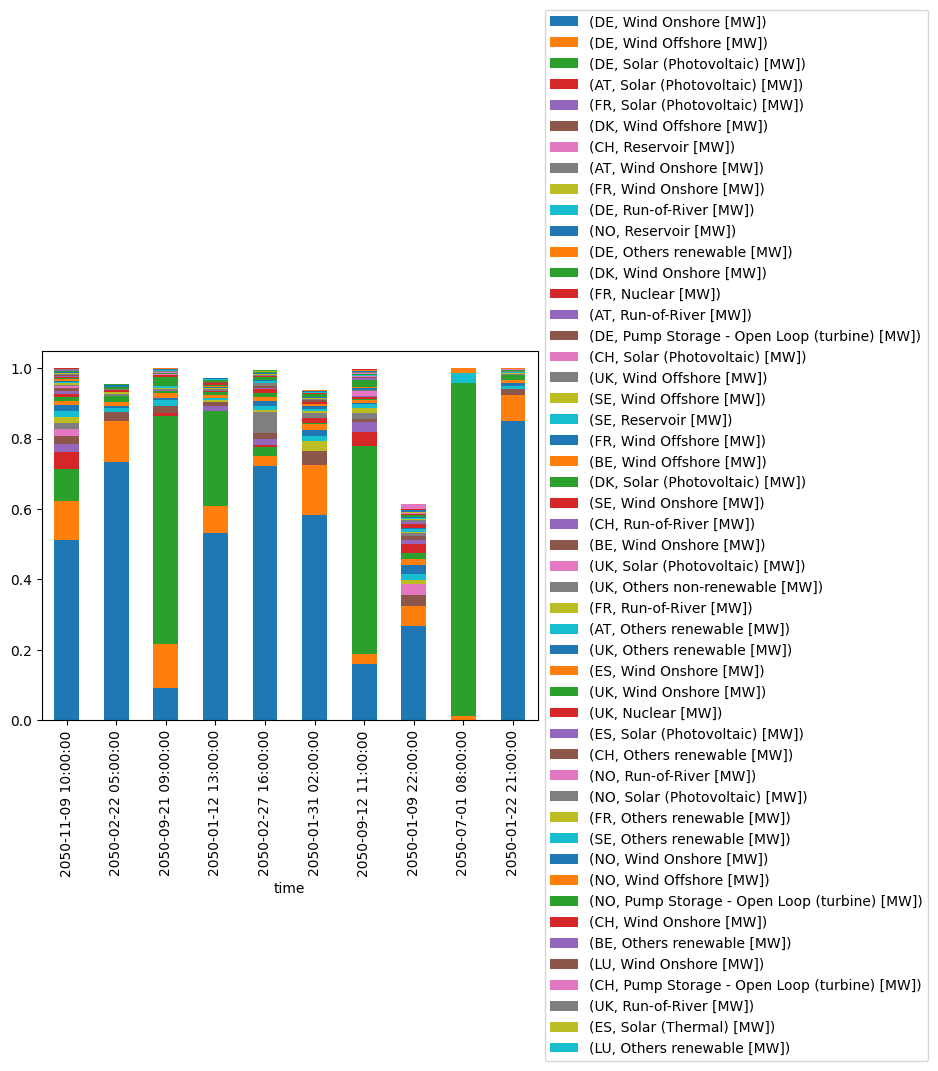

In [135]:
t = Z_gross.index[np.random.randint(8736, size=10)]
c = "DE"

ax = (
    consumption_mix_xr.sel(consumer_country=c, time=t)
    .to_dataframe()["consumption_mix"]
    .unstack("time")
    .nlargest(columns=t[0], n=50)
    .T.plot.bar(stacked=True)
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))